<a href="https://colab.research.google.com/github/marcuslee6/Signal-and-Systems/blob/main/analog%20to%20digital%20converter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

目標數位頻率: 100.0 Hz
預扭曲後的類比角頻率 (Warped Omega): 649.84 rad/s

--- 類比系統係數 (s-domain) ---
b (分子多項式): [422291.23600034]
a (分母多項式): [1.00000000e+00 9.19011682e+02 4.22291236e+05] 

--- 轉換後的數位系統係數 (z-domain差分方程) ---
b_digital (分子 1/z 項): [0.06745527 0.13491055 0.06745527]
a_digital (分母 1/z 項): [ 1.        -1.1429805  0.4128016] 



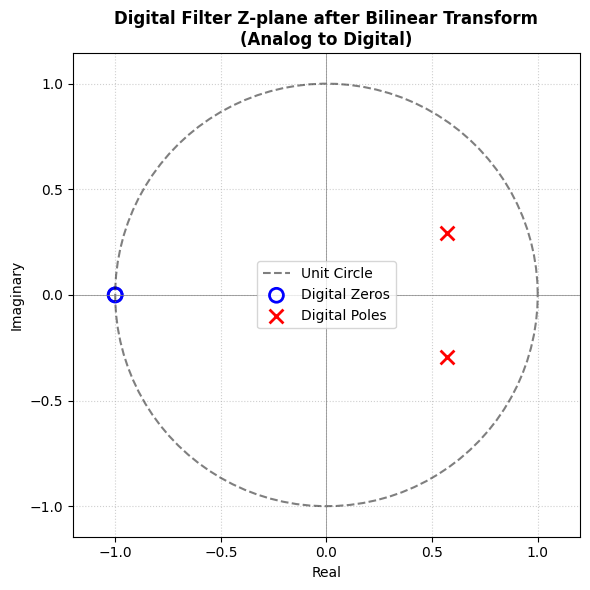

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# =========================================================================
# 1. Define parameters
# =========================================================================
fs = 1000.0 # Sampling Rate = 1000 Hz
Ts = 1.0 / fs # Sampling period
fc_target = 100.0 # Target cut-off frequency of filter after conversion as 100 Hz

# =========================================================================
# 2. Pre-warping
# Calculate analog angular frequency to make sure cut-off frequency as 100 Hz (Analog angular frequency, warped)
# =========================================================================
w_digital = 2 * np.pi * fc_target
w_analog_warped = (2 / Ts) * np.tan(w_digital * Ts / 2)
print(f"目標數位頻率: {fc_target} Hz")
print(f"預扭曲後的類比角頻率 (Warped Omega): {w_analog_warped:.2f} rad/s\n")

# =========================================================================
# 3. Analog Filter Design
# Design 2 step butterworth low pass filter，set cut-off frquency as w_analog_warped
# =========================================================================
b_analog, a_analog = signal.butter(N=2, Wn=w_analog_warped, btype='low', analog=True)
print("--- 類比系統係數 (s-domain) ---")
print("b (分子多項式):", b_analog)
print("a (分母多項式):", a_analog, "\n")

# =========================================================================
# 4. Bilinear Transformation: Analog -> Digital
# =========================================================================
b_digital, a_digital = signal.bilinear(b_analog, a_analog, fs=fs)
print("--- 轉換後的數位系統係數 (z-domain差分方程) ---")
print("b_digital (分子 1/z 項):", b_digital)
print("a_digital (分母 1/z 項):", a_digital, "\n")

# =========================================================================
# 5. Verify results: Z-plane Pole-Zero Plot
# =========================================================================
zeros_d = np.roots(b_digital)
poles_d = np.roots(a_digital)

fig, ax = plt.subplots(figsize=(6, 6))

# draw unit circle
theta = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5, label='Unit Circle')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)

# Draw zeroes and poles
if len(zeros_d) > 0:
  ax.scatter(np.real(zeros_d), np.imag(zeros_d), s=100, facecolors='none', edgecolors='blue', marker='o', lw=2, label='Digital Zeros')
if len(poles_d) > 0:
  ax.scatter(np.real(poles_d), np.imag(poles_d), s=100, color='red', marker='x', lw=2, label='Digital Poles')

ax.set_title("Digital Filter Z-plane after Bilinear Transform\n(Analog to Digital)", fontsize=12, fontweight='bold')
ax.set_xlabel('Real')
ax.set_ylabel('Imaginary')
ax.axis('equal')
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend()

plt.tight_layout()
plt.show()
